In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../src")

from _visualization import *
import _mapping

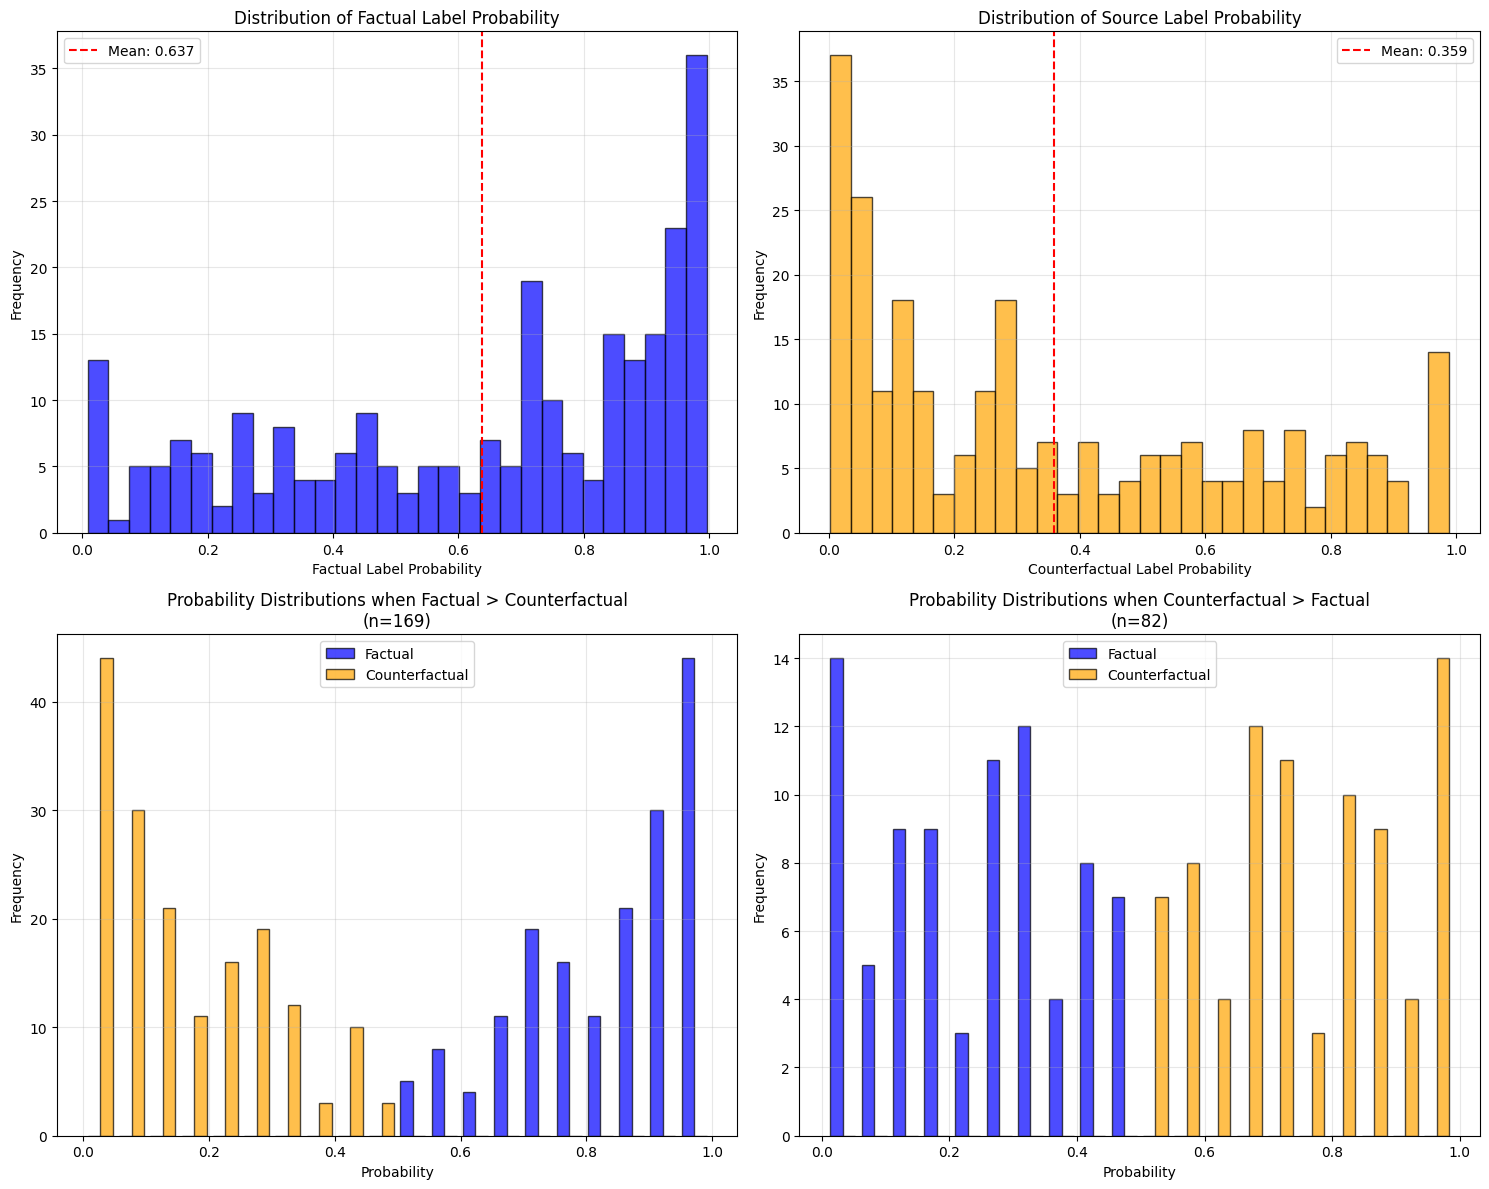

In [19]:
probability_filepath = "../experiments/activation_intervention/output/GPT-OSS/result_unfaithful_source/h_pre_result_all_layers_user_question_and_restatement.csv"
plot_probability_distributions(probability_filepath)

Total rows: 256
Factual answers: 256
Counterfactual answers: 0
Factual accuracy: 100.00%
Counterfactual accuracy: 0.00%


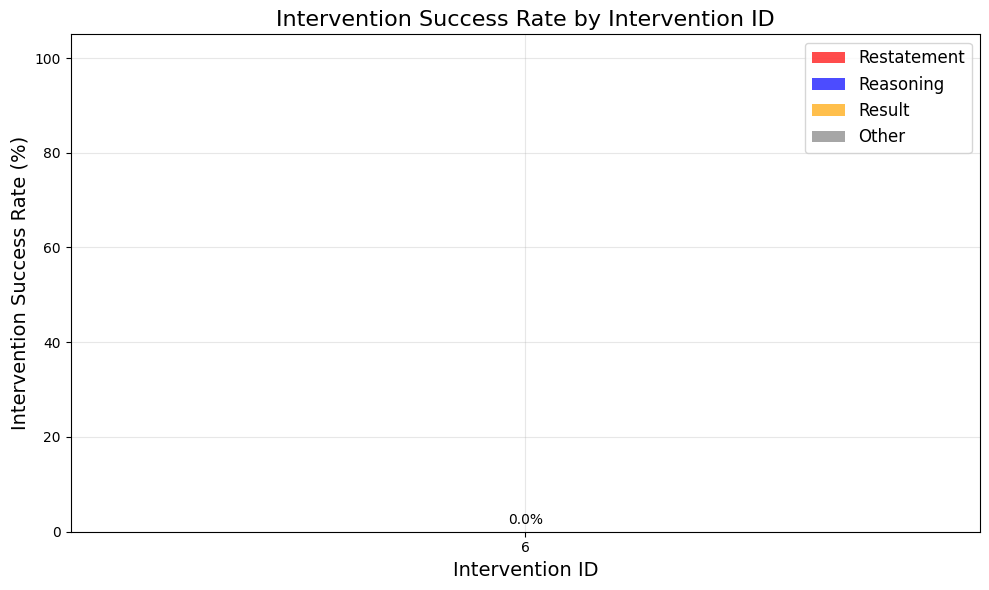


Detailed Statistics by Intervention ID:
Intervention success rate ratios:
  Intervention ID 6: 0.0% intervention success rate (n=256)


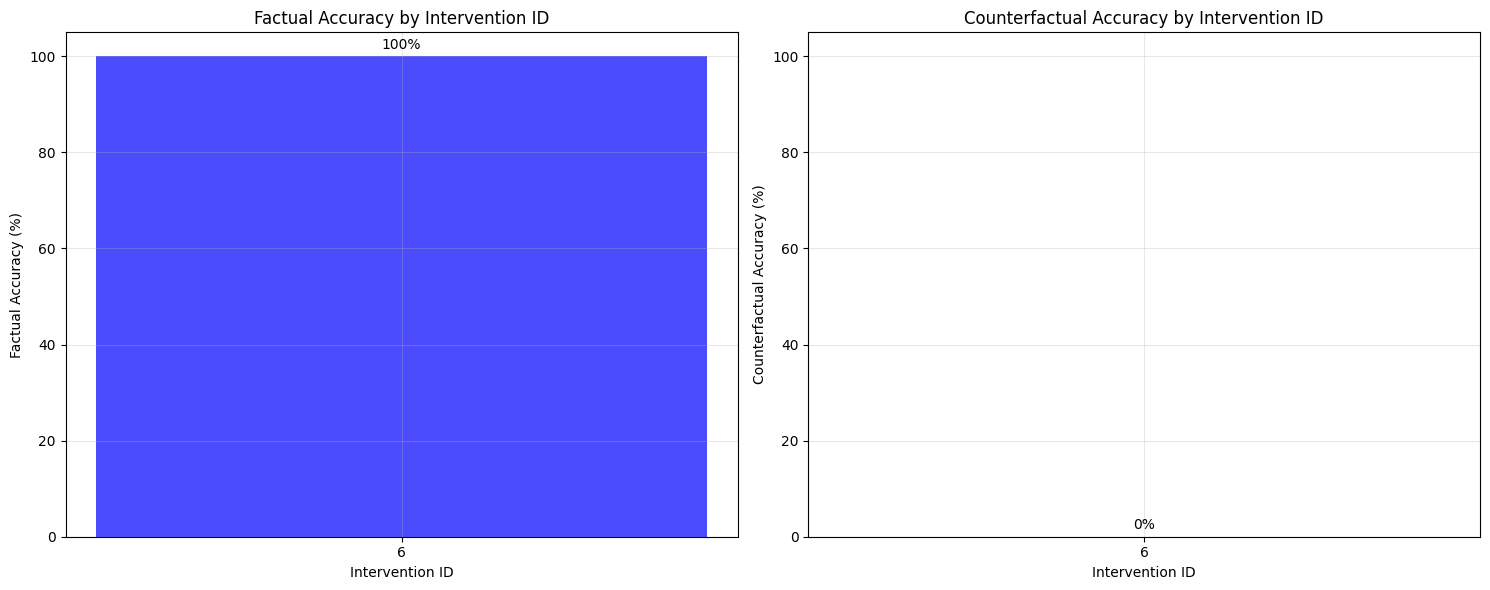


Detailed Statistics by Intervention ID:
Factual accuracy ratios:
  Intervention ID 6: 100.0% factual accuracy (n=256)

Counterfactual accuracy ratios:
  Intervention ID 6: 0.0% counterfactual accuracy (n=256)


In [13]:
accuracy_results = get_accuracy("../experiments/activation_intervention/output/GPT-OSS/result_unfaithful_source/h_pre_result_user_question.csv", output_type="immediate")
# accuracy_results = get_accuracy("../experiments/token_intervention/output/GPT-OSS/generation_h.csv", output_type="final_output")
plot_intervention_success_rate_by_location(accuracy_results, _mapping.intervene_ids_stepwise_3_digit)
plot_intervention_results_by_location(accuracy_results)

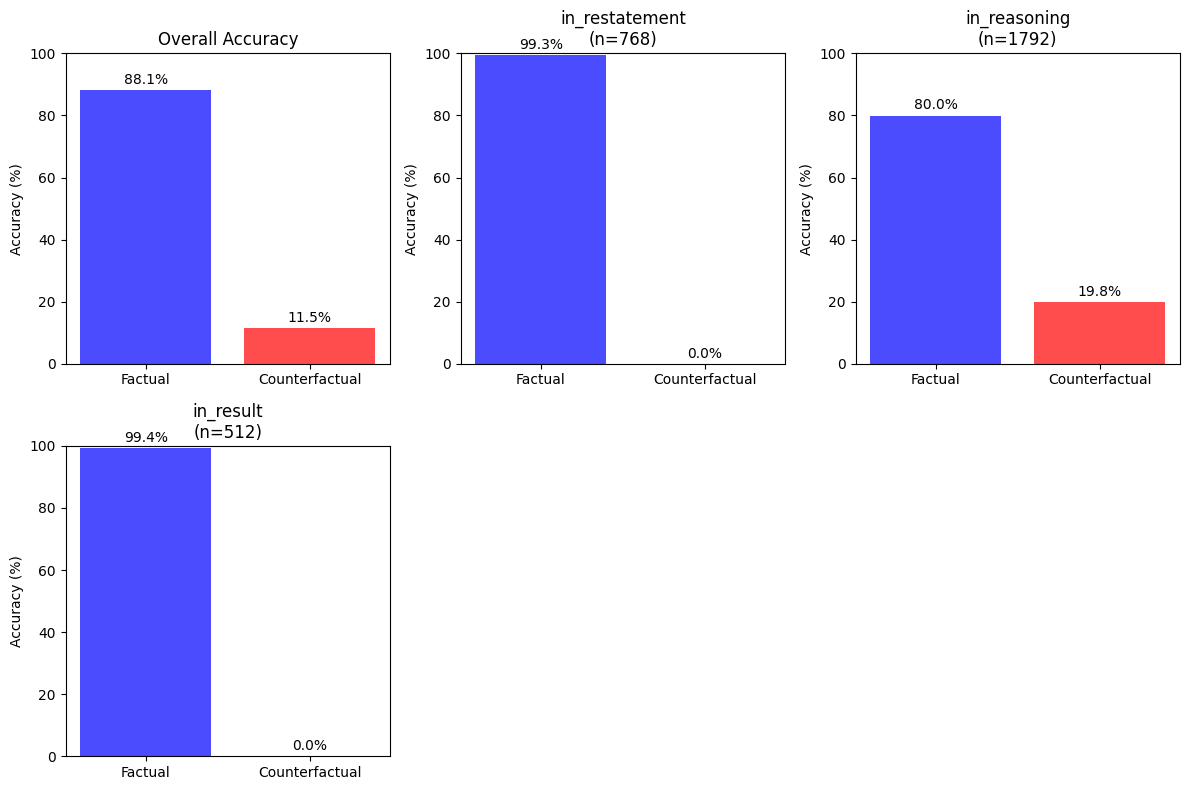


Detailed Statistics:
Overall - Factual: 88.05%, Counterfactual: 11.52%
in_restatement - Factual: 99.35%, Counterfactual: 0.00% (n=768)
in_reasoning - Factual: 79.97%, Counterfactual: 19.75% (n=1792)
in_result - Factual: 99.41%, Counterfactual: 0.00% (n=512)


In [24]:
plot_intervention_results_by_type(accuracy_results)

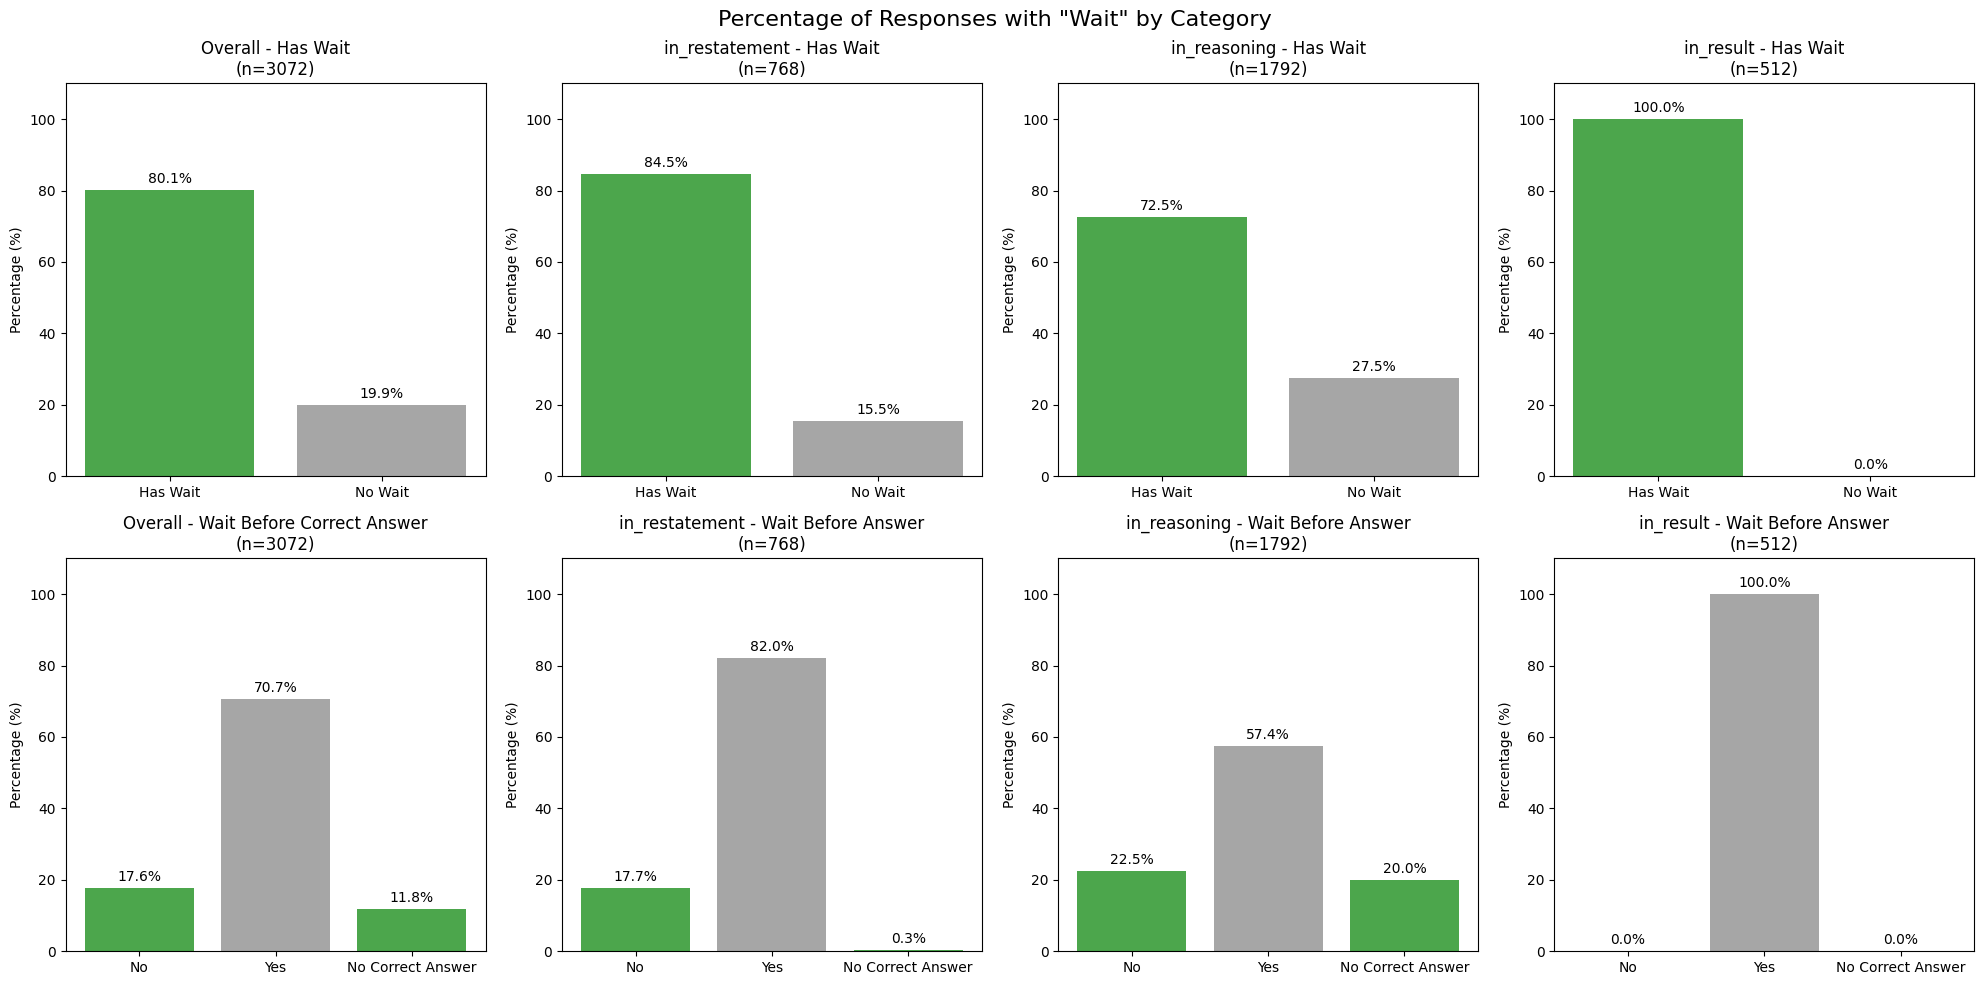

In [41]:
plot_wait_ratio(accuracy_results)

In [42]:
# Print rows where in_restatement is True and has_wait_before_answer is 0
filtered_rows = accuracy_results[(accuracy_results['in_reasoning'] == True) & (accuracy_results['has_wait_before_answer'] == 0)]

print(f"Found {len(filtered_rows)} rows where in_restatement is True and has_wait_before_answer is 0:")
print("=" * 80)

for idx, row in filtered_rows.iterrows():
    print(f"Row {idx}:")
    print(f"  base_1_num: {row['base_1_num']}")
    print(f"  base_2_num: {row['base_2_num']}")
    print(f"  base_sum: {row['base_sum']}")
    print(f"  intervention_id: {row['intervention_id']}")
    print(f"  is_factual: {row['is_factual']}")
    print(f"  is_counterfactual: {row['is_counterfactual']}")
    print(f"  generated_text: {row['generated_text'][:200]}...")  # First 200 chars
    print("-" * 40)


Found 404 rows where in_restatement is True and has_wait_before_answer is 0:
Row 4:
  base_1_num: 204
  base_2_num: 443
  base_sum: 647
  intervention_id: 18
  is_factual: True
  is_counterfactual: False
  generated_text:  = 404, +200 = 604, +40 = 644, +3 = 647. Or do column addition: 204 + 443 = 647. So the sum is 647. In final, just output "647".<|end|><|start|>assistant<|channel|>final<|message|>647<|return|>...
----------------------------------------
Row 15:
  base_1_num: 410
  base_2_num: 452
  base_sum: 862
  intervention_id: 14
  is_factual: True
  is_counterfactual: False
  generated_text:  - 48 = 910 - 48 = 862. Or do column addition: 410 + 452 = 410 + 400 + 52 = 810 + 52 = 862. So the sum is 862. In final, just output "862".<|end|><|start|>assistant<|channel|>final<|message|>862<|retu...
----------------------------------------
Row 29:
  base_1_num: 130
  base_2_num: 675
  base_sum: 805
  intervention_id: 19
  is_factual: True
  is_counterfactual: False
  generated_text: , 3

In [14]:
import pandas as pd

# Read both CSV files
token_df = pd.read_csv("../experiments/token_intervention/output/R1/fixed_reasoning_h_pre_result.csv")
activation_df = pd.read_csv("../experiments/activation_intervention/output/R1/layer_0_h_pre_result.csv")

# Compare generated_text entries and print differences
print("Rows where generated_text differs between token and activation intervention:")
print("=" * 70)

for i in range(min(len(token_df), len(activation_df))):
    token_text = token_df.iloc[i]['generated_text']
    activation_text = activation_df.iloc[i]['generated_text']
    
    if token_text != activation_text:
        base_1_num = token_df.iloc[i]['base_1_num']
        base_2_num = token_df.iloc[i]['base_2_num']
        intervention_id = token_df.iloc[i]['intervention_id']
        print(f"Row {i}: base_1_num={base_1_num}, base_2_num={base_2_num}, intervention_id={intervention_id}")

# Also check if the files have different lengths
if len(token_df) != len(activation_df):
    print(f"\nNote: Files have different lengths - Token: {len(token_df)}, Activation: {len(activation_df)}")


Rows where generated_text differs between token and activation intervention:
Row 11: base_1_num=201, base_2_num=337, intervention_id=13
Row 33: base_1_num=136, base_2_num=652, intervention_id=4
Row 51: base_1_num=629, base_2_num=235, intervention_id=4
Row 60: base_1_num=267, base_2_num=213, intervention_id=4
Row 61: base_1_num=267, base_2_num=213, intervention_id=12
Row 62: base_1_num=267, base_2_num=213, intervention_id=13
Row 67: base_1_num=202, base_2_num=558, intervention_id=12
Row 105: base_1_num=318, base_2_num=299, intervention_id=4
Row 112: base_1_num=292, base_2_num=657, intervention_id=12
Row 115: base_1_num=457, base_2_num=443, intervention_id=12
Row 135: base_1_num=101, base_2_num=154, intervention_id=4
Row 148: base_1_num=415, base_2_num=385, intervention_id=12
Row 149: base_1_num=415, base_2_num=385, intervention_id=13
Row 153: base_1_num=291, base_2_num=199, intervention_id=4
Row 165: base_1_num=167, base_2_num=494, intervention_id=4
Row 168: base_1_num=384, base_2_num=4